# Conservatively diagnosing model transports across arbitrary sections with `sectionate`

## Import packages

In [1]:
import numpy as np
import xgcm
import xarray as xr
import matplotlib.pyplot as plt

import sectionate
print(f"Sectionate version: {sectionate.__version__}")

Sectionate version: 0.3.3


## Load example model grid and transport diagnosics

In [2]:
from load_example_model_grid import load_MOM6_example_grid
grid = load_MOM6_example_grid()
ds = grid._ds

/Users/henrifdrake/anaconda3/envs/docs_env_sectionate/lib/python3.13/site-packages/xgcm/grid.py:477: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(


## Define the two OSNAP sections:

In [3]:
west_section_lats = [52.0166, 52.6648, 53.5577, 58.8944, 60.4000]
west_section_lons = [-56.8775, -52.0956, -49.8604, -47.6107, -44.8000]

east_section_lats = [60.4000, 58.8600, 58.0500, 58.0000, 56.5000]
east_section_lons = [-44.8000, -30.5400, -28.0000, -14.7000, -5.9300]

total_section_lats = west_section_lats + east_section_lats
total_section_lons = west_section_lons + east_section_lons

## West section

In [4]:
i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    west_section_lons,
    west_section_lats,
)

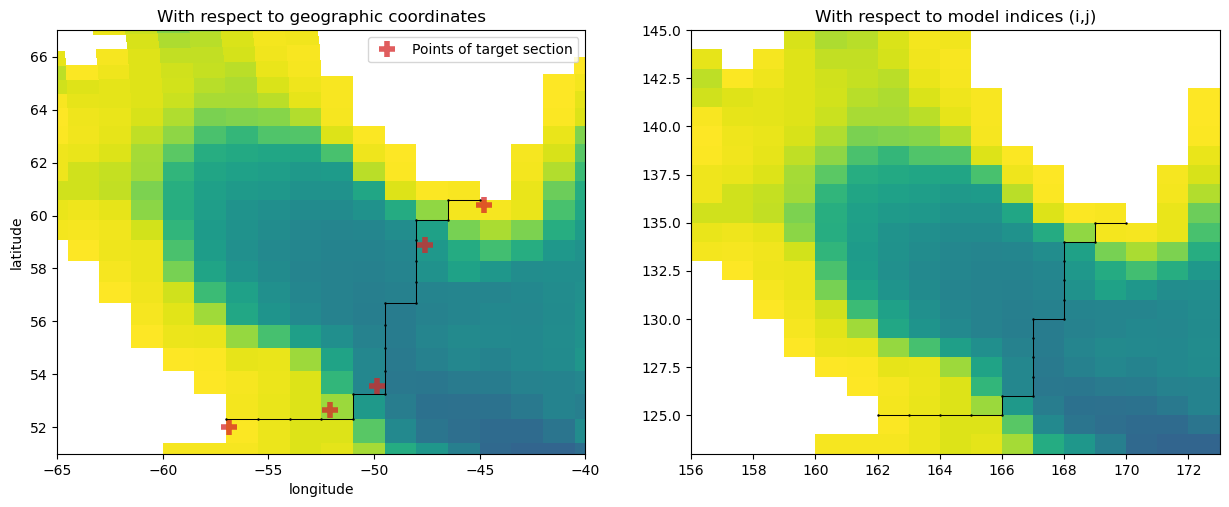

In [5]:
plt.figure(figsize=[15,5.5])
plt.subplot(1,2,1)
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), cmap="viridis_r")
plt.plot(west_section_lons, west_section_lats, "C3+", markersize=12., mew=4., alpha=0.75, label="Points of target section")
plt.plot(lons_c, lats_c, 'k.-', markersize=1.5, lw=0.75)
plt.axis([-65,-40, 51, 67])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("With respect to geographic coordinates")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.pcolormesh(ds['deptho'].where(ds['deptho']!=0).values, cmap="viridis_r")
plt.plot(i_c, j_c, 'k.-', markersize=1.5, lw=0.75)
plt.axis([156, 173, 123, 145])
plt.title("With respect to model indices (i,j)")
plt.show()

### Plot cell-integrated mass transport across the section

In [6]:
Trp_west = sectionate.convergent_transport(grid, i_c, j_c, layer="sigma2_l", interface="sigma2_i")

/Users/henrifdrake/code/sectionate/sectionate/transports.py:531: UserWarning: This section is open (its first and last waypoints are far apart), so it does not enclose a polygon and the inward/outward sense of `positive_in` is undefined. Sectionate applies the left-of-transect convention instead: with `positive_in=True` positive transport points to the LEFT of the section as it is traversed from the first to the last waypoint (set `positive_in=False` to flip to right-of-transect). Verify the sign matches your expectations, e.g. by plotting the section's normal vectors.
  warnings.warn(


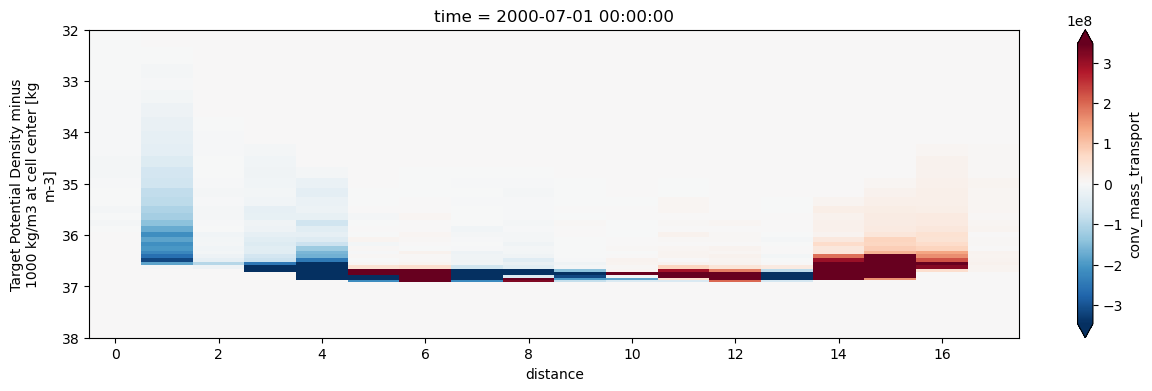

In [7]:
plt.figure(figsize=(15, 4))
Trp_west.isel(time=0)['conv_mass_transport'].swap_dims({'sect':'distance'}).plot(cmap='RdBu_r', x="distance", yincrease=False, ylim=[38,32], robust=True);

### Visualizing the normal vectors to understand the orientation of the cross-section transports

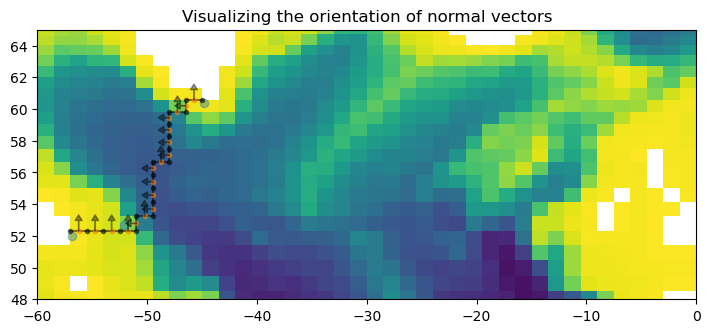

In [8]:
plt.figure(figsize=(8.5, 3.5))
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), vmin=0, vmax=5000, cmap="viridis_r")

plt.plot(west_section_lons, west_section_lats, "C0o", alpha=0.4)
for (p, (var, lon, lat, sign)) in enumerate(zip(
    Trp_west.dir.values,
    Trp_west.lon.values,
    Trp_west.lat.values,
    Trp_west.sign.values
    )):
    if var=="V":
        efact = 0.
        nfact = sign 
    if var=="U":
        efact = sign
        nfact = 0.

    plt.annotate(
        '', xy=(lon+float(efact), lat+float(nfact)),  xycoords='data',
        xytext=(lon, lat),
        arrowprops=dict(facecolor='black', shrink=0.01, width=0.25, headwidth=5., headlength=4., alpha=0.4),
        horizontalalignment='center', verticalalignment='center'
    )
plt.plot(lons_c, lats_c, "ko-", alpha=0.5, markersize=3, label="tracer cell corners (vorticity grid)")
plt.plot(Trp_west.lon, Trp_west.lat, "C1o", alpha=0.5, lw=1, markersize=3, label="velocity cells (faces normal to section)");
plt.title("Visualizing the orientation of normal vectors")
plt.axis([-60, 0, 48, 65]);

Because this is an *open* section, `convergent_transport` applies the **left-of-transect convention**: positive transport points to the left of the section as it is traversed from the first to the last waypoint. The West section is traced from west to east, so its default normal vectors point **northward** (as the arrows above confirm).

We reverse the sign so that the AMOC's deep *southward* transport is positive:

In [9]:
Trp_west = -Trp_west

## East section

In [10]:
i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    east_section_lons,
    east_section_lats,
)

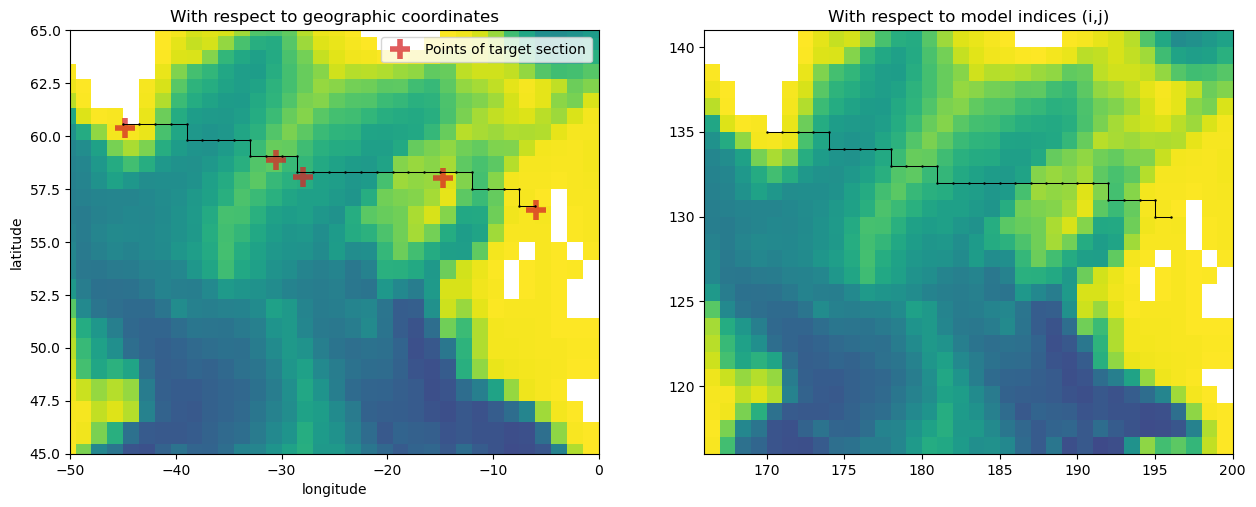

In [11]:
plt.figure(figsize=[15,5.5])
plt.subplot(1,2,1)
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), cmap="viridis_r")
plt.plot(east_section_lons, east_section_lats, "C3+", markersize=15., mew=4., alpha=0.75, label="Points of target section")
plt.plot(lons_c, lats_c, 'k.-', markersize=1.5, lw=0.75)
plt.axis([-50, 0, 45, 65])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("With respect to geographic coordinates")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.pcolormesh(ds['deptho'].where(ds['deptho']!=0), cmap="viridis_r")
plt.plot(i_c, j_c, 'k.-', markersize=1.5, lw=0.75)
plt.axis([166, 200, 116, 141])
plt.title("With respect to model indices (i,j)")
plt.show()

### Plot the cell-integrated mass transport across the section

In [12]:
Trp_east = sectionate.convergent_transport(grid, i_c, j_c, layer="sigma2_l", interface="sigma2_i")

/Users/henrifdrake/code/sectionate/sectionate/transports.py:531: UserWarning: This section is open (its first and last waypoints are far apart), so it does not enclose a polygon and the inward/outward sense of `positive_in` is undefined. Sectionate applies the left-of-transect convention instead: with `positive_in=True` positive transport points to the LEFT of the section as it is traversed from the first to the last waypoint (set `positive_in=False` to flip to right-of-transect). Verify the sign matches your expectations, e.g. by plotting the section's normal vectors.
  warnings.warn(


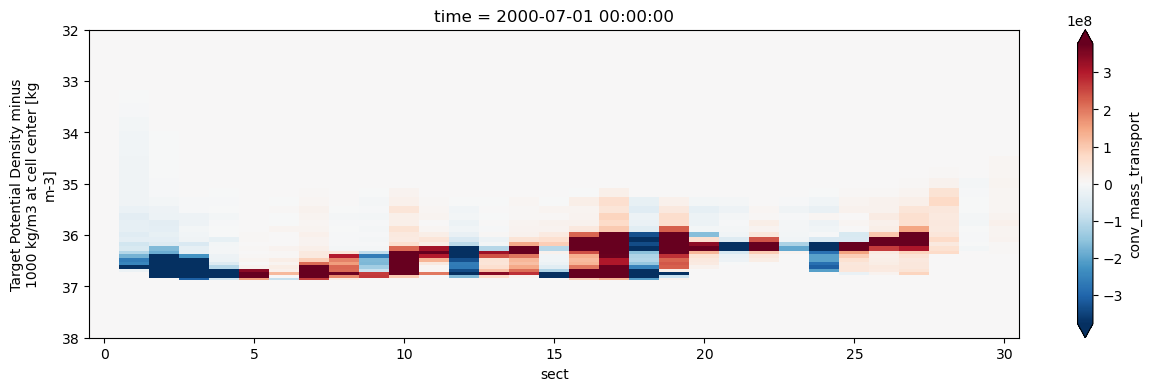

In [13]:
plt.figure(figsize=(15, 4))
Trp_east.isel(time=0)['conv_mass_transport'].plot(cmap='RdBu_r', x="sect", yincrease=False, ylim=[38,32], robust=True);

### Visualizing the normal vectors to understand the orientation of the cross-section transports

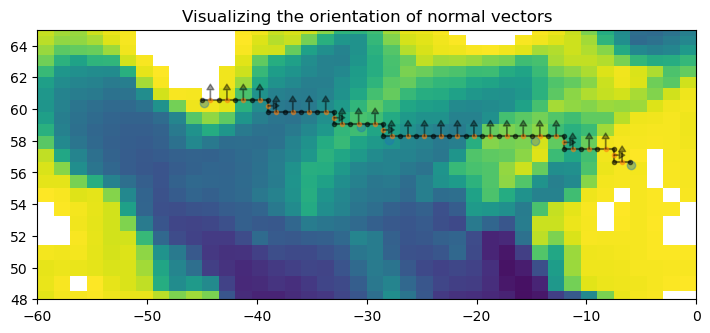

In [14]:
plt.figure(figsize=(8.5, 3.5))
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), vmin=0, vmax=5000, cmap="viridis_r")

plt.plot(east_section_lons, east_section_lats, "C0o", alpha=0.4)
for (p, (var, lon, lat, sign)) in enumerate(zip(
    Trp_east.dir.values,
    Trp_east.lon.values,
    Trp_east.lat.values,
    Trp_east.sign.values
    )):
    if var=="V":
        efact = 0.
        nfact = sign 
    if var=="U":
        efact = sign
        nfact = 0.

    plt.annotate(
        '', xy=(lon+float(efact), lat+float(nfact)),  xycoords='data',
        xytext=(lon, lat),
        arrowprops=dict(facecolor='black', shrink=0.01, width=0.25, headwidth=5., headlength=4., alpha=0.4),
        horizontalalignment='center', verticalalignment='center'
    )
plt.plot(lons_c, lats_c, "ko-", alpha=0.5, markersize=3, label="tracer cell corners (vorticity grid)")
plt.plot(Trp_east.lon, Trp_east.lat, "C1o", alpha=0.5, lw=1, markersize=3, label="velocity cells (faces normal to section)");
plt.title("Visualizing the orientation of normal vectors")
plt.axis([-60, 0, 48, 65]);

The East section is *also* traced from west to east, so by the same left-of-transect convention its default normal vectors point **northward** too. We therefore reverse its sign as well, so that southward transport is positive:

In [15]:
Trp_east = -Trp_east

## Both sections together

In [16]:
i_c, j_c, lons_c, lats_c = sectionate.grid_section(
    grid,
    total_section_lons,
    total_section_lats,
)

In [17]:
Trp = sectionate.convergent_transport(grid, i_c, j_c, layer="sigma2_l", interface="sigma2_i")

/Users/henrifdrake/code/sectionate/sectionate/transports.py:531: UserWarning: This section is open (its first and last waypoints are far apart), so it does not enclose a polygon and the inward/outward sense of `positive_in` is undefined. Sectionate applies the left-of-transect convention instead: with `positive_in=True` positive transport points to the LEFT of the section as it is traversed from the first to the last waypoint (set `positive_in=False` to flip to right-of-transect). Verify the sign matches your expectations, e.g. by plotting the section's normal vectors.
  warnings.warn(


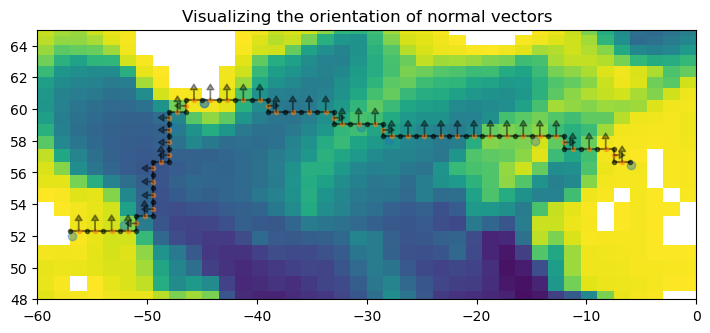

In [18]:
plt.figure(figsize=(8.5, 3.5))
plt.pcolormesh(ds['geolon_c'], ds['geolat_c'], ds['deptho'].where(ds['deptho']!=0), vmin=0, vmax=5000, cmap="viridis_r")

plt.plot(total_section_lons, total_section_lats, "C0o", alpha=0.4)
for (p, (var, lon, lat, sign)) in enumerate(zip(
    Trp.dir.values,
    Trp.lon.values,
    Trp.lat.values,
    Trp.sign.values
    )):
    if var=="V":
        efact = 0.
        nfact = sign 
    if var=="U":
        efact = sign
        nfact = 0.

    plt.annotate(
        '', xy=(lon+float(efact), lat+float(nfact)),  xycoords='data',
        xytext=(lon, lat),
        arrowprops=dict(facecolor='black', shrink=0.01, width=0.25, headwidth=5., headlength=4., alpha=0.4),
        horizontalalignment='center', verticalalignment='center'
    )
plt.plot(lons_c, lats_c, "ko-", alpha=0.5, markersize=3, label="tracer cell corners (vorticity grid)")
plt.plot(Trp.lon, Trp.lat, "C1o", alpha=0.5, lw=1, markersize=3, label="velocity cells (faces normal to section)");
plt.title("Visualizing the orientation of normal vectors")
plt.axis([-60, 0, 48, 65]);

The combined section is likewise traced from west to east, so its default normals also point northward. We reverse its sign too, keeping all three sections on a consistent southward-positive convention (so that `OSNAP Total` matches `OSNAP-West + OSNAP-East` below):

In [19]:
Trp = -Trp

## Diagnosing overturning streamfunctions in density space

In [20]:
rho0 = 1035. # kg/m3
Sv_s_per_m3 = 1e-6
Sv_s_per_kg = Sv_s_per_m3/rho0
ovt_rho2_west = Trp_west["conv_mass_transport"].cumsum("sigma2_l").sum("sect") *Sv_s_per_kg
ovt_rho2_east = Trp_east["conv_mass_transport"].cumsum("sigma2_l").sum("sect") *Sv_s_per_kg
ovt_rho2 = Trp["conv_mass_transport"].cumsum("sigma2_l").sum("sect") *Sv_s_per_kg

### OSNAP Total Residual Transport

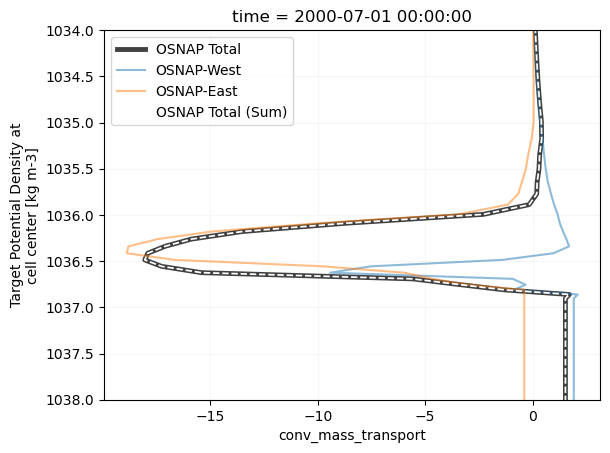

In [21]:
(ovt_rho2).isel(time=0).plot(y='rho2_l', yincrease=False, ylim=[1038,1034], label="OSNAP Total", color="k", lw=3.5, alpha=0.75)
ovt_rho2_west.isel(time=0).plot(y='rho2_l', yincrease=False, ylim=[1038,1034], label="OSNAP-West", alpha=0.5, ls="-")
ovt_rho2_east.isel(time=0).plot(y='rho2_l', yincrease=False, ylim=[1038,1034], label="OSNAP-East", alpha=0.5, ls="-")
(ovt_rho2_east + ovt_rho2_west).isel(time=0).plot(y='rho2_l', yincrease=False, ylim=[1038,1034], label="OSNAP Total (Sum)", color="white", ls="--", lw=1.25)
plt.legend();
plt.grid(True, alpha=0.1)